In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import tqdm
from IPython.display import clear_output
from scipy.stats import ks_2samp, wasserstein_distance
from scipy.spatial.distance import jensenshannon
from itertools import product
from pathlib import Path

%matplotlib inline

In [2]:

folder = "G:\Meu Drive\mestrado_final_files\simulations\\NGramModel_ExtraInfo_MultiTowers\\"
folder = "G:\Meu Drive\mestrado_final_files\simulations\\NGramModel_ExtraInfo\\"

In [3]:
pd.set_option("display.max_columns", None)

In [4]:
def get_model_features(file):

    model_features = file.split("\\")[-1].split("/")[-1]\
    .replace(".parquet", "")\
    .replace("simulations_", "")\
    .replace("_seasondata", ";seasondata?")\
    .replace("_context", ";context?")\
    .replace("_embedding", ";embedding?")\
    .replace("_numlayers", ";numlayers?")\
    .replace("_numneurons", ";numneurons?")\
    .replace("_nodropout", ";dropout?0")\
    .replace("_dropout0", ";dropout?0.")\
    .replace("_layernorm", ";layernorm?")\
    .replace("_setcovariables", ";setcovariables?")\
    .split(";")

    return pd.DataFrame(data = model_features, columns = ["key_value"])\
    .reset_index()\
    .assign(key = lambda df: np.where(df["index"] == 0, "model", ""))\
    .assign(value = lambda df: np.where(df["index"] == 0, df["key_value"], ""))\
    .assign(key_value = lambda df: df["key_value"].str.split("?"))\
    .assign(key = lambda df: np.where(df["index"] != 0, df["key_value"].apply(lambda x: x[0]), df["key"]))\
    .assign(value = lambda df: np.where(df["index"] != 0, df["key_value"].apply(lambda x: x[-1]), df["value"]))\
    .assign(aux = 1)\
    .pivot_table(index = "aux", columns = "key", values = "value", aggfunc = lambda x: x)\
    .reset_index(drop = True)\
    [["model", "seasondata", "context", "embedding", "numlayers", "numneurons", "dropout", "layernorm", "setcovariables"]]

def build_mean_points(df_):
    # malha de tempo (descendo 7200 -> 0 de 10 em 10)
    times = np.arange(7200, -1, -10, dtype=np.int16)

    # filtra só tempos regulamentares
    df = df_.loc[df_["period"].le(4), ["sim_id", "period", "remaining_time", "home_points", "away_points"]].copy()

    # arredonda/encaixa no grid de 10s (use int pra acelerar)
    df["remaining_time_secs"] = (df["remaining_time"].astype(np.int32) // 10 * 10).astype(np.int16)

    # ordena pra shift/ffill funcionarem direito (tempo desc)
    df = df.sort_values(["sim_id", "period", "remaining_time_secs"], ascending=[True, True, False])

    # detecta mudanças de placar DENTRO de cada sim_id+period (vetorizado)
    g = df.groupby(["sim_id", "period"], sort=False)
    h_prev = g["home_points"].shift(1)
    a_prev = g["away_points"].shift(1)

    changed = df["home_points"].ne(h_prev) | df["away_points"].ne(a_prev)
    start_q = df["remaining_time_secs"].eq(7200)

    df = df.loc[changed | start_q]

    # consolida: um valor por (sim_id, period, time)
    df = (
        df.groupby(["sim_id", "period", "remaining_time_secs"], as_index=False, sort=False)[["home_points", "away_points"]]
          .max()
    )

    out_parts = []
    # processa por período pra reduzir pico de memória
    for p, dpp in df.groupby("period", sort=False):
        sims = dpp["sim_id"].unique()

        # MultiIndex completo: (sim_id x time)
        full_idx = pd.MultiIndex.from_product(
            [sims, times],
            names=["sim_id", "remaining_time_secs"]
        )

        # reindex + ffill por sim_id
        dpp2 = (
            dpp.set_index(["sim_id", "remaining_time_secs"])[["home_points", "away_points"]]
               .reindex(full_idx)
               .groupby(level=0, sort=False)
               .ffill()
        )

        # agrega média no período
        mean_pp = dpp2.groupby(level=1, sort=False).mean(numeric_only=True)
        mean_pp = mean_pp.reset_index()
        mean_pp.insert(0, "period", p)

        out_parts.append(mean_pp)

    out = (
        pd.concat(out_parts, ignore_index=True)
          .sort_values(["period", "remaining_time_secs"], ascending=[True, False], ignore_index=True)
    )
    return out

def get_points_by_categorical_variables_complete_time(df_):
    list_labels = [
        "a. ( <= -20)", "b. (entre -19 e -11)", "c. (entre -10 e -7)",
        "d. (entre -6 e -4)", "e. (entre -3 e -1)", "f. empatado",
        "g. (entre 1 e 3)", "h. (entre 4 e 6)", "i. (entre 7 e 10)",
        "j. (entre 11 e 19)", "k. ( >= 20)"
    ]
    list_time_marks = [-1, 100, 200, 600, 1200, 1800, 2400, 3000, 3600, 4200, 4800, 5400, 6000, 6600, 7200]

    # rótulos do cat_time: primeiro vira 0 (no seu código você converte -1 -> 0)
    time_labels = list_time_marks[:-1].copy()
    time_labels[0] = 0
    time_labels = np.array(time_labels, dtype = np.int16)

    # 1) base + cat_time
    df = df_.query("period <= 4")[["sim_id", "period", "remaining_time", "home_points", "away_points"]].copy()

    df["cat_time"] = pd.cut(df["remaining_time"], bins = list_time_marks, labels = time_labels).astype("int16")

    # 2) garante unicidade (senão dá o erro de multiindex duplicado)
    df = (
        df.groupby(["sim_id", "period", "cat_time"], as_index = False, sort = False)[["home_points", "away_points"]]
          .max()
    )

    # 3) COMPLETA A GRADE (sim_id x cat_time) dentro de cada period e faz ffill por sim_id
    parts = []
    for p, dpp in df.groupby("period", sort = False):
        sims = dpp["sim_id"].unique()

        full_idx = pd.MultiIndex.from_product(
            [sims, time_labels],
            names=["sim_id", "cat_time"]
        )

        filled = (
            dpp.set_index(["sim_id", "cat_time"])[["home_points", "away_points"]]
               .reindex(full_idx)
               .groupby(level = 0, sort = False)
               .bfill()
               .reset_index()
        )
        filled.insert(1, "period", p)
        parts.append(filled)

    df_full = pd.concat(parts, ignore_index = True)

    # 4) segue sua lógica original (agora com todos cat_time presentes)
    df_full = (
        df_full
        .sort_values(["sim_id", "period", "cat_time"], ascending=[True, True, False])
        .assign(lag_hp = lambda d: d.groupby("sim_id")["home_points"].shift(1).fillna(0))
        .assign(lag_ap = lambda d: d.groupby("sim_id")["away_points"].shift(1).fillna(0))
        .assign(dif = lambda d: d["lag_hp"] - d["lag_ap"])
        .assign(cat_dif = lambda d: pd.cut(d["dif"],
            bins = [-100, -19.5, -10.5, -6.5, -3.5, -0.5, 0.5, 3.5, 6.5, 10.5, 19.5, 100],
            labels = list_labels
        ).astype("str"))
        # lags iguais ao seu código: por sim_id (carrega entre períodos)
        .assign(hp = lambda d: d["home_points"] - d["lag_hp"])
        .assign(ap = lambda d: d["away_points"] - d["lag_ap"])
        .assign(cnt = 1)

        .groupby(["period", "cat_time", "cat_dif"], as_index = False, dropna = False)
        .agg({"cnt": "sum", "hp": "mean", "ap": "mean"})
        .sort_values(["period", "cat_time", "cat_dif"], ascending = [True, False, True])

    )



    return df_full

def get_ks_statistics(var1, var2):

    resultado_ks = ks_2samp(data1 = var1, data2 = var2)
    df_resultado_ks = pd.DataFrame([{"ks_statistic": resultado_ks.statistic,
                                     "ks_pvalue": resultado_ks.pvalue,
                                     "ks_statistic_location": resultado_ks.statistic_location,
                                     "ks_statistic_sign": resultado_ks.statistic_sign}])
    return df_resultado_ks

def get_jensen_shannon_statistic(var1, var2):
    var1 = np.asarray(var1)
    var2 = np.asarray(var2)

    # remover NA, se houver
    var1 = var1[~np.isnan(var1)]
    var2 = var2[~np.isnan(var2)]

    # se uma das amostras estiver vazia, não há como comparar
    if len(var1) == 0 or len(var2) == 0:
        return np.nan

    min_score = min(var1.min(), var2.min())
    max_score = max(var1.max(), var2.max())
    support = np.arange(min_score, max_score + 1)

    real_counts = np.array([(var1 == s).sum() for s in support], dtype=float)
    sim_counts  = np.array([(var2 == s).sum() for s in support], dtype=float)

    real_total = real_counts.sum()
    sim_total = sim_counts.sum()

    # proteção extra
    if real_total == 0 or sim_total == 0:
        return np.nan

    real_probs = real_counts / real_total
    sim_probs  = sim_counts / sim_total

    dist_js = jensenshannon(real_probs, sim_probs)
    return dist_js

def get_comparative_distribution_metrics(var1, var2):

    ks_ = get_ks_statistics(var1, var2)
    wasserstein_ = wasserstein_distance(var1, var2)
    js_ = get_jensen_shannon_statistic(var1, var2)

    final_df = ks_\
    .assign(wasserstein_distance = wasserstein_)\
    .assign(jensen_shannon = js_)

    return final_df

def create_base_df_period_cat_time_cat_dif() -> pd.DataFrame:
    periods = [1, 2, 3, 4]

    cat_dif = [
        "a. ( <= -20)", "b. (entre -19 e -11)", "c. (entre -10 e -7)",
        "d. (entre -6 e -4)", "e. (entre -3 e -1)", "f. empatado",
        "g. (entre 1 e 3)", "h. (entre 4 e 6)", "i. (entre 7 e 10)",
        "j. (entre 11 e 19)", "k. ( >= 20)"
    ]

    cat_time = [0, 100, 200, 600, 1200, 1800, 2400, 3000, 3600, 4200, 4800, 5400, 6000, 6600]

    df_base = pd.DataFrame(
        product(periods, cat_time, cat_dif),
        columns=["period", "cat_time", "cat_dif"]
    )

    return df_base

def get_metrics_cat_diff_time_variables(df):
    mae_prop = np.abs(df["error_prop"]).mean()
    max_error_prop = np.abs(df["error_prop"]).max()
    rmse_prop = np.sqrt((df["error_prop"] ** 2).mean())

    # máscaras
    mask_hp = df["error_hp"].notna() & df["real_prop"].notna()
    mask_ap = df["error_ap"].notna() & df["real_prop"].notna()

    # coverage
    coverage_hp = mask_hp.sum() / df["real_hp"].notna().sum()
    coverage_ap = mask_ap.sum() / df["real_ap"].notna().sum()

    # pesos
    w_hp = df.loc[mask_hp, "real_prop"]
    w_ap = df.loc[mask_ap, "real_prop"]

    # hp
    mae_hp = (w_hp * np.abs(df.loc[mask_hp, "error_hp"])).sum() / w_hp.sum()
    rmse_hp = np.sqrt((w_hp * (df.loc[mask_hp, "error_hp"] ** 2)).sum() / w_hp.sum())

    corr_pearson_hp = df.loc[mask_hp, ["real_hp", "hp"]].corr(method="pearson").iloc[0, 1]
    corr_spearman_hp = df.loc[mask_hp, ["real_hp", "hp"]].corr(method="spearman").iloc[0, 1]

    # ap
    mae_ap = (w_ap * np.abs(df.loc[mask_ap, "error_ap"])).sum() / w_ap.sum()
    rmse_ap = np.sqrt((w_ap * (df.loc[mask_ap, "error_ap"] ** 2)).sum() / w_ap.sum())

    corr_pearson_ap = df.loc[mask_ap, ["real_ap", "ap"]].corr(method="pearson").iloc[0, 1]
    corr_spearman_ap = df.loc[mask_ap, ["real_ap", "ap"]].corr(method="spearman").iloc[0, 1]

    df_final = pd.DataFrame({
        "mae_prop": [mae_prop],
        "max_error_prop": [max_error_prop],
        "rmse_prop": [rmse_prop],
        "coverage_hp": [coverage_hp],
        "mae_hp": [mae_hp],
        "rmse_hp": [rmse_hp],
        "corr_pearson_hp": [corr_pearson_hp],
        "corr_spearman_hp": [corr_spearman_hp],
        "coverage_ap": [coverage_ap],
        "mae_ap": [mae_ap],
        "rmse_ap": [rmse_ap],
        "corr_pearson_ap": [corr_pearson_ap],
        "corr_spearman_ap": [corr_spearman_ap]
    })

    return df_final

def get_prop_tp_tokens(df, dict_tokens):
    df_ = df\
    .assign(token_ = lambda df: df["token"].map(dict_tokens))\
    .assign(tp_token = lambda df: df["token_"].str.replace("\)p", ");p", regex = True).str.replace("p[0-9]{3}_", "", regex = True))\
    .assign(tp_token = lambda df: df["tp_token"].str.replace("\(.+?\)", "", regex = True).str.split(";"))

    return pd.DataFrame(data = df_["tp_token"].to_list(), index = df_.index)\
    .stack().reset_index()\
    .rename(columns = {0: "tp_token"})\
    .astype({"tp_token": "int"})\
    .set_index("level_0")\
    .merge(df_[["sim_id"]], how = "left", left_index = True, right_index  = True)\
    .assign(num_sim = lambda df: df["sim_id"].nunique())\
    .groupby(["num_sim", "tp_token"], as_index = False, dropna = False).size()\
    .assign(prop = lambda df: df["size"] / df["num_sim"])\
    [["tp_token", "prop"]]

def get_match_splits(df, num_secs = 300):
    num_breaks = [i for i in range(0, 7201, num_secs)]
    num_labels = [str(i) + "-" + str(j) for i, j in zip(num_breaks[:-1], num_breaks[1:])]
    num_breaks[0] -= 1
    num_breaks[-1] += 1
    return df.assign(cat_time = lambda df: pd.cut(df["remaining_time"], bins = num_breaks, labels = num_labels))

def get_stats_simulations(file, dict_real_values, dict_tokens):
    
    if isinstance(file, str): 
        df_ = pd.read_parquet(file)
        df_features_model = get_model_features(file)

    if isinstance(file, list): 
        list_df = []
        for ff in file:
            df_ = pd.read_parquet(ff)
            list_df.append(df_)

        df_ = pd.concat(list_df).reset_index(drop = True)
        df_features_model = get_model_features(file[0].split("_parte")[0])

    dict_stats = {}
    dict_comparison = {}

    # final outcome
    df_final_points = df_.query("period <= 4")\
    .groupby("sim_id")[["home_points", "away_points"]].max()\
    .assign(dif = lambda df: df["home_points"] - df["away_points"])

    df_outcome = df_final_points\
    .assign(outcome = lambda df: np.where(df["home_points"] > df["away_points"], "home_win", "draw"))\
    .assign(outcome = lambda df: np.where(df["home_points"] < df["away_points"], "away_win", df["outcome"]))\
    .groupby("outcome", as_index = False).size()\
    .assign(perc = lambda df: df["size"] / df["size"].sum())\
    .assign(aux = 1)\
    .pivot_table(index = "aux", columns = "outcome", values = "perc")\
    .reset_index(drop = True)

    dict_stats["outcome"] = df_features_model.assign(aux = 1)\
    .merge(df_outcome.assign(aux = 1), how = "left")\
    .drop(columns = "aux")


    dict_comparison["outcome"] = dict_stats["outcome"]\
    .merge(dict_real_values["outcome"], how = "left")\
    .assign(dif_prop_away = lambda df: df["away_win"] - df["real_away_win"])\
    .assign(dif_prop_draw = lambda df: df["draw"] - df["real_draw"])\
    .assign(dif_prop_away = lambda df: np.abs(df["dif_prop_away"]) / df["real_away_win"])\
    .assign(dif_prop_draw = lambda df: np.abs(df["dif_prop_draw"]) / df["real_draw"])

    # final points
    df_real_data_points_season = dict_real_values["final_points"].loc[dict_real_values["final_points"]["season"] == df_features_model["seasondata"][0]]

    df_points_stats = df_final_points[["home_points", "away_points"]].describe(percentiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T\
    .reset_index().rename(columns = {"index": "team"})

    dict_stats["points_stats"] = df_features_model.assign(aux = 1)\
    .merge(df_points_stats.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    df_comparative_hpts = get_comparative_distribution_metrics(df_real_data_points_season["hpts"], df_final_points['home_points'])
    df_comparative_apts = get_comparative_distribution_metrics(df_real_data_points_season["vpts"], df_final_points['away_points'])
    df_comparative_difpts = get_comparative_distribution_metrics(df_real_data_points_season["dif"], df_final_points['dif'])

    dict_comparison["comparative_home_points"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_hpts.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_away_points"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_apts.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_dif_points"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_difpts.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    # num_plays
    df_real_data_nplays_season = dict_real_values["nplays_period"].loc[dict_real_values["nplays_period"]["season"] == df_features_model["seasondata"][0]]

    df_num_plays = df_\
    .groupby(["sim_id", "period"], as_index = False).size()

    df_num_plays_stats = df_num_plays\
    .assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))\
    .groupby("period")["size"].describe(percentiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])\
    .reset_index()

    dict_stats["num_plays"] = df_features_model.assign(aux = 1)\
    .merge(df_num_plays_stats.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    df_comparative_nplays_1stp = get_comparative_distribution_metrics(df_real_data_nplays_season.query("period == 1")["size"], df_num_plays.query("period == 1")["size"])
    df_comparative_nplays_2ndp = get_comparative_distribution_metrics(df_real_data_nplays_season.query("period == 2")["size"], df_num_plays.query("period == 2")["size"])
    df_comparative_nplays_3rdp = get_comparative_distribution_metrics(df_real_data_nplays_season.query("period == 3")["size"], df_num_plays.query("period == 3")["size"])
    df_comparative_nplays_4thp = get_comparative_distribution_metrics(df_real_data_nplays_season.query("period == 4")["size"], df_num_plays.query("period == 4")["size"])
    df_comparative_nplays_overtime = get_comparative_distribution_metrics(df_real_data_nplays_season.query("period > 4")["size"], df_num_plays.query("period > 4")["size"])

    dict_comparison["comparative_nplays_1st_period"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_nplays_1stp.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_nplays_2nd_period"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_nplays_2ndp.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_nplays_3rd_period"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_nplays_3rdp.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_nplays_4th_period"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_nplays_4thp.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_nplays_overtime"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_nplays_overtime.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    # num_plays by 20secs strip
    df_real_data_nplays_by_20secs_season = dict_real_values["ntokens_20secs_strip"].loc[dict_real_values["ntokens_20secs_strip"]["season"] == df_features_model["seasondata"][0]]

    df_num_plays_by_20secs = df_\
    .pipe(get_match_splits, num_secs = 200)\
    .query("period <= 5")\
    .assign(num_games = lambda df: df.groupby(["period"])["sim_id"].transform("nunique"))\
    .groupby(["num_games", "period", "cat_time"], as_index = False, dropna = False, observed = True).size()\
    .assign(media_ntokens = lambda df: df["size"] / df["num_games"])\
    [["period", "cat_time", "media_ntokens"]]

    dict_stats["nplays_by_20secs_strip"] = df_features_model.assign(aux = 1)\
    .merge(df_num_plays_by_20secs.assign(aux = 1), how = "left")\
    .drop(columns = "aux")\
    .sort_values(["period", "cat_time"], ascending = [True, False]).reset_index(drop = True)

    dict_comparison["nplays_by_20secs_strip"] = dict_stats["nplays_by_20secs_strip"]\
    .merge(df_real_data_nplays_by_20secs_season, how = "left")\
    .assign(dif_media_ntokens = lambda df: df["media_ntokens"] - df["real_media_ntokens"])\
    .sort_values(["period", "cat_time"], ascending = [True, False]).reset_index(drop = True)

    # mean points by secs
    df_real_mean_points_by_seconds_season = dict_real_values["points_by_secs"].loc[dict_real_values["points_by_secs"]["season"] == df_features_model["seasondata"][0]]
    df_mean_points_by_seconds = build_mean_points(df_)

    dict_stats["points_by_secs"] = df_features_model.assign(aux = 1)\
    .merge(df_mean_points_by_seconds.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    df_comparative_points_by_secs_hpts = get_comparative_distribution_metrics(df_real_mean_points_by_seconds_season["home_points"], df_mean_points_by_seconds["home_points"])
    df_comparative_points_by_secs_apts = get_comparative_distribution_metrics(df_real_mean_points_by_seconds_season["away_points"], df_mean_points_by_seconds["away_points"])

    dict_comparison["comparative_home_points_by_secs"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_points_by_secs_hpts.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_away_points_by_secs"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_points_by_secs_apts.assign(aux = 1), how = "left")\
    .drop(columns = "aux")


    # points by dif and time
    df_real_points_categorical_dif_and_time_season = dict_real_values["points_by_categorical_dif_time"].loc[dict_real_values["points_by_categorical_dif_time"]["season"] == df_features_model["seasondata"][0]]

    df_points_categorical_dif_and_time = get_points_by_categorical_variables_complete_time(df_ = df_)\
    .assign(total_cnt = lambda df: df.groupby(["period", "cat_time"])["cnt"].transform("sum"))\
    .assign(sim_prop = lambda df: df["cnt"] / df["total_cnt"])

    dict_stats["points_by_cat_time_dif"] = df_features_model.assign(aux = 1)\
    .merge(df_points_categorical_dif_and_time.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    df_comparative_time_diff = create_base_df_period_cat_time_cat_dif()\
    .merge(df_real_points_categorical_dif_and_time_season, how = 'left')\
    .assign(real_prop = lambda df: df["real_prop"].fillna(0))\
    .merge(df_points_categorical_dif_and_time[["period", "cat_time", "cat_dif", "sim_prop", "hp", "ap"]], how = "left")\
    .assign(sim_prop = lambda df: df["sim_prop"].fillna(0))\
    .assign(error_prop = lambda df: df["real_prop"] - df["sim_prop"])\
    .assign(error_hp = lambda df: df["real_hp"] - df["hp"])\
    .assign(error_ap = lambda df: df["real_ap"] - df["ap"])

    df_first46mins_time_dif_metrics = get_metrics_cat_diff_time_variables(df_comparative_time_diff.query("~(period == 4 & cat_time <= 600)"))

    df_final2mins_time_dif_metrics = get_metrics_cat_diff_time_variables(df_comparative_time_diff.query("period == 4 & cat_time <= 600"))

    dict_comparison["comparative_cat_time_diff_first46mins"] = df_features_model.assign(aux = 1)\
    .merge(df_first46mins_time_dif_metrics.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_cat_time_diff_final2mins"] = df_features_model.assign(aux = 1)\
    .merge(df_final2mins_time_dif_metrics.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    # lead changes
    df_real_lead_changes_season = dict_real_values["lead_changes"].loc[dict_real_values["lead_changes"]["season"] == df_features_model["seasondata"][0]]

    df_lead_changes = df_\
    .assign(dif = lambda df: df["home_points"] - df["away_points"])\
    .assign(leading = lambda df: np.sign(df["dif"]))\
    .query("dif != 0")\
    .assign(lead_change = lambda df: df.groupby("sim_id")["leading"].diff().fillna(0))\
    .assign(lead_change = lambda df: np.where(df["lead_change"] == 0, 0, 1))\
    .groupby(["sim_id"], as_index = False, dropna = False)["lead_change"].sum()\
    .rename(columns = {"lead_change": "lead_changes"})

    df_lead_changes_stats = df_lead_changes[["lead_changes"]].describe(percentiles = [.01, .05, .1, .25, .5, .75, .9, .95, .99]).T

    dict_stats["lead_changes"] = df_features_model.assign(aux = 1)\
    .merge(df_lead_changes_stats.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    df_comparative_lead_changes = get_comparative_distribution_metrics(df_real_lead_changes_season["real_lead_changes"], df_lead_changes["lead_changes"])

    dict_comparison["comparative_lead_changes"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_lead_changes.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    # dist points by minutes
    df_real_points_by_minutes_season = dict_real_values["points_by_minutes"].loc[dict_real_values["points_by_minutes"]["season"] == df_features_model["seasondata"][0]]

    df_points_by_minutes = df_\
    .pipe(get_match_splits, num_secs = 600)\
    .assign(hpts_dif = lambda df: df.groupby("sim_id")["home_points"].diff().fillna(0))\
    .assign(apts_dif = lambda df: df.groupby("sim_id")["away_points"].diff().fillna(0))\
    .groupby(["sim_id", "period", "cat_time"], as_index = False, dropna = False, observed = True)[["hpts_dif", "apts_dif"]].sum()\
    .assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))

    df_points_by_minutes_home_stats = df_points_by_minutes\
    .groupby(["period", "cat_time"], as_index = False, dropna = False, observed = True)["hpts_dif"].describe(percentiles = [.01, .05, .1, .25, .5, .75, .9, .95, .99])

    df_points_by_minutes_away_stats = df_points_by_minutes\
    .groupby(["period", "cat_time"], as_index = False, dropna = False, observed = True)["apts_dif"].describe(percentiles = [.01, .05, .1, .25, .5, .75, .9, .95, .99])

    dict_stats["points_by_minutes_home"] = df_features_model.assign(aux = 1)\
    .merge(df_points_by_minutes_home_stats.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_stats["points_by_minutes_away"] = df_features_model.assign(aux = 1)\
    .merge(df_points_by_minutes_away_stats.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    df_comparative_points_by_minutes_hpts = get_comparative_distribution_metrics(df_real_points_by_minutes_season["hpts_dif"], df_points_by_minutes["hpts_dif"])
    df_comparative_points_by_minutes_apts = get_comparative_distribution_metrics(df_real_points_by_minutes_season["apts_dif"], df_points_by_minutes["apts_dif"])

    dict_comparison["comparative_incremento_hp_by_minute"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_points_by_minutes_hpts.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    dict_comparison["comparative_incremento_ap_by_minute"] = df_features_model.assign(aux = 1)\
    .merge(df_comparative_points_by_minutes_apts.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    # prop_tp_tokens
    df_prop_tp_tokens = get_prop_tp_tokens(df_, dict_tokens)

    dict_stats["prop_tp_tokens"] = df_features_model.assign(aux = 1)\
    .merge(df_prop_tp_tokens.assign(aux = 1), how = "left")\
    .drop(columns = "aux")

    df_real_prop_tokens = dict_real_values["prop_tp_tokens_dist"].loc[dict_real_values["prop_tp_tokens_dist"]["season"] == df_features_model["seasondata"][0]]

    dict_comparison["prop_tp_tokens"] = dict_stats["prop_tp_tokens"]\
    .merge(df_real_prop_tokens, how = "left")\
    .assign(dif_props = lambda df: df["prop"] - df["real_prop"])

    dict_results = {"comparison": dict_comparison, "stats": dict_stats}
    return dict_results

In [5]:
data_folder = "G:\Meu Drive\mestrado_final_files\data\\"
#data_folder = "drive/MyDrive/mestrado_final_files/data/"

In [6]:
tokens_info = pd.read_csv(data_folder + 'tokens_info.txt', sep = ';')\
.sort_values(['cod', 'token'])\
.set_index('token')

list_tokens = tokens_info.index.to_list()

# Create a dictionary mapping each token to a unique integer, starting from 1
token_to_integer = {tok: idx + 1 for idx, tok in enumerate(list_tokens)}

# Assign a special integer (0) for the period (.)
token_to_integer['.'] = 0

# Create an inverse mapping from integers back to tokens
integer_to_token = {idx: tok for tok, idx in token_to_integer.items()}


In [7]:
tokens_timeout_home_team = ['p550_1(1a)p200_9(0)', 'p500_1(3)p200_9(0)', 'p550_1(3a)p200_9(0)',
                            'p550_1(3a)p200_9(0)p440_8(0)', 'p550_1(5a)p200_9(0)', 'p200_9(0)',
                            'p200_9(0)p001_18(0)', 'p200_9(0)p440_8(0)', 'p200_9(0)p550_8(0)',
                            'p200_9(0)p440_8(0)p440_8(0)', 'p200_9(0)p440_8(0)p550_8(0)',
                            'p200_9(0)p550_8(0)p550_8(0)', 'p200_9(0)p440_8(0)p440_8(0)p440_8(0)',
                            'p200_9(0)p440_8(0)p440_8(0)p550_8(0)', 'p200_9(0)p440_8(0)p550_8(0)p550_8(0)',
                            'p200_9(0)p440_8(0)p440_8(0)p440_8(0)p550_8(0)',
                            'p200_9(0)p440_8(0)p440_8(0)p550_8(0)p550_8(0)', 'p200_9(1)', 'p200_9(1)p001_18(0)']

tokens_timeout_away_team = ['p440_1(1a)p300_9(0)', 'p440_1(1a)p300_9(0)p550_8(0)', 'p400_1(3)p300_9(0)',
                            'p440_1(3a)p300_9(0)', 'p440_1(3a)p300_9(0)p550_8(0)', 'p440_1(5a)p300_9(0)',
                            'p300_9(0)', 'p300_9(0)p001_18(0)', 'p300_9(0)p440_8(0)', 'p300_9(0)p550_8(0)',
                            'p300_9(0)p440_8(0)p440_8(0)', 'p300_9(0)p440_8(0)p550_8(0)', 'p300_9(0)p550_8(0)p550_8(0)',
                            'p300_9(0)p440_8(0)p440_8(0)p550_8(0)', 'p300_9(0)p440_8(0)p550_8(0)p550_8(0)',
                            'p300_9(0)p550_8(0)p550_8(0)p550_8(0)', 'p300_9(0)p440_8(0)p440_8(0)p550_8(0)p550_8(0)',
                            'p300_9(0)p440_8(0)p550_8(0)p550_8(0)p550_8(0)',
                            'p300_9(0)p440_8(0)p440_8(0)p550_8(0)p550_8(0)p550_8(0)', 'p300_9(1)', 'p300_9(1)p001_18(0)']

In [93]:

pbp_tokenized = pd.read_csv(data_folder + "pbp_tokenized.txt", sep = ";")
df_games_nba = pd.read_csv(data_folder + "games_nba.csv", sep = ';')\
.rename(columns = {"GAME_ID": "game_id", "SEASON": "season"})\
.assign(season = lambda df: df["season"].str.replace("\-", "", regex = True))

full_pbp_tokenized = pbp_tokenized\
.merge(df_games_nba[["game_id", "season"]].drop_duplicates(), how = "left")\
.assign(tp_token = lambda df: df["token"].str.replace("\)p", ");p", regex = True).str.replace("p[0-9]{3}_", "", regex = True))\
.assign(tp_token = lambda df: df["tp_token"].str.replace("\(.+?\)", "", regex = True).str.split(";"))\
.assign(token_int = lambda df: df["token"].map(token_to_integer))

del pbp_tokenized

In [94]:
dict_real_values = {}

dict_real_values["final_points"] = full_pbp_tokenized.query("period <= 4")\
.groupby(["season", "game_id"], as_index = False, dropna = False)[["hpts", "vpts"]].max()\
.assign(dif = lambda df: df["hpts"] - df["vpts"])

dict_real_values["nplays_period"] = full_pbp_tokenized\
.query("period <= 4")\
.groupby(["season", "game_id", "period"], as_index = False, dropna = False).size()

dict_real_values["points_by_secs"] = full_pbp_tokenized\
.rename(columns = {"hpts": "home_points", "vpts": "away_points", "game_id": "sim_id", "time": "remaining_time"})\
.groupby("season")\
.apply(func = build_mean_points, include_groups = False)\
.reset_index("season")

dict_real_values["points_by_categorical_dif_time"] = full_pbp_tokenized\
.rename(columns = {"hpts": "home_points", "vpts": "away_points", "game_id": "sim_id", "time": "remaining_time"})\
.groupby("season")\
.apply(func = get_points_by_categorical_variables_complete_time, include_groups = False)\
.reset_index("season")\
.assign(total_cnt = lambda df: df.groupby(["season", "period", "cat_time"])["cnt"].transform("sum"))\
.assign(real_prop = lambda df: df["cnt"] / df["total_cnt"])\
.rename(columns = {"hp": "real_hp", "ap": "real_ap"})

dict_real_values["prop_tp_tokens_dist"] = pd.DataFrame(data = full_pbp_tokenized["tp_token"].to_list(),
                                                       index = full_pbp_tokenized.index)\
.stack().reset_index()\
.rename(columns = {0: "tp_token"})\
.astype({"tp_token": "int"})\
.set_index("level_0")\
.merge(full_pbp_tokenized[["game_id", "season"]], how = "left", left_index = True, right_index  = True)\
.assign(num_games = lambda df: df.groupby("season")["game_id"].transform("nunique"))\
.groupby(["season", "num_games", "tp_token"], as_index = False, dropna = False).size()\
.assign(real_prop = lambda df: df["size"] / df["num_games"])

dict_real_values["lead_changes"] = full_pbp_tokenized\
.query("period  <= 4")\
.assign(leading = lambda df: np.sign(df["dif"]))\
.query("dif != 0")\
.assign(lead_change = lambda df: df.groupby("game_id")["leading"].diff().fillna(0))\
.assign(lead_change = lambda df: np.where(df["lead_change"] == 0, 0, 1))\
.groupby(["season", "game_id"], as_index = False, dropna = False)["lead_change"].sum()\
.rename(columns = {"lead_change": "real_lead_changes"})

dict_real_values["ntokens_20secs_strip"] = full_pbp_tokenized\
.rename(columns = {"time": "remaining_time"})\
.query("period <= 5")\
.pipe(get_match_splits, num_secs = 200)\
.assign(num_games = lambda df: df.groupby(["season", "period"])["game_id"].transform("nunique"))\
.groupby(["season", "num_games", "period", "cat_time"], as_index = False, dropna = False, observed = True).size()\
.assign(real_media_ntokens = lambda df: df["size"] / df["num_games"])\
[["season", "period", "cat_time", "real_media_ntokens"]]

dict_real_values["points_by_minutes"] = full_pbp_tokenized\
.rename(columns = {"time": "remaining_time"})\
.pipe(get_match_splits, num_secs = 600)\
.assign(hpts_dif = lambda df: df.groupby("game_id")["hpts"].diff().fillna(0))\
.assign(apts_dif = lambda df: df.groupby("game_id")["vpts"].diff().fillna(0))\
.groupby(["season", "game_id", "period", "cat_time"], as_index = False, dropna = False, observed = True)[["hpts_dif", "apts_dif"]].sum()\
.assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))

dict_real_values["outcome"]  = dict_real_values["final_points"]\
.assign(outcome = lambda df: np.where(df["hpts"] > df["vpts"], "real_home_win", "real_draw"))\
.assign(outcome = lambda df: np.where(df["hpts"] < df["vpts"], "real_away_win", df["outcome"]))\
.groupby(["season", "outcome"], as_index = False).size()\
.assign(size_season = lambda df: df.groupby("season")["size"].transform("sum"))\
.assign(perc = lambda df: df["size"] / df["size_season"])\
.pivot_table(index = "season", columns = "outcome", values = "perc")\
.reset_index()\
.rename(columns = {"season": "seasondata"})

In [95]:
del full_pbp_tokenized

In [11]:
simulations_folder = "../simulations/"
summary_simulations_folder = "../summary_simulations/"


In [28]:
file = [simulations_folder + "FinalSimulations/" + folder for folder in os.listdir(simulations_folder + "FinalSimulations") if ".ini" not in folder]

In [29]:
file

['../simulations/FinalSimulations/simulations_NGramModel_ExtraInfo_seasondata201819_context5_embedding32_numlayers3_numneurons50_nodropout_layernormFalse_setcovariables2_parte1.parquet',
 '../simulations/FinalSimulations/simulations_NGramModel_ExtraInfo_seasondata201819_context5_embedding32_numlayers3_numneurons50_nodropout_layernormFalse_setcovariables2_parte2.parquet',
 '../simulations/FinalSimulations/simulations_NGramModel_ExtraInfo_seasondata201819_context5_embedding32_numlayers3_numneurons50_nodropout_layernormFalse_setcovariables2_parte3.parquet',
 '../simulations/FinalSimulations/simulations_NGramModel_ExtraInfo_seasondata201819_context5_embedding32_numlayers3_numneurons50_nodropout_layernormFalse_setcovariables2_parte4.parquet',
 '../simulations/FinalSimulations/simulations_NGramModel_ExtraInfo_seasondata201819_context5_embedding32_numlayers3_numneurons50_nodropout_layernormFalse_setcovariables2_parte5.parquet',
 '../simulations/FinalSimulations/simulations_NGramModel_ExtraInf

In [96]:
list_final_points = []
list_num_plays = []
list_lead_changes = []

In [97]:
for file_ in tqdm.tqdm(file):
    df_ = pd.read_parquet(file_)

    df_features_model = get_model_features(file_.split("_parte")[0])

    df_final_points = df_.query("period <= 4")\
    .groupby("sim_id")[["home_points", "away_points"]].max()\
    .assign(dif = lambda df: df["home_points"] - df["away_points"])\
    .assign(aux = 1).merge(df_features_model.assign(aux = 1), how = "inner", on = "aux").drop(columns = "aux")

    list_final_points.append(df_final_points)

    df_num_plays = df_\
    .groupby(["sim_id", "period"], as_index = False).size()\
    .assign(aux = 1).merge(df_features_model.assign(aux = 1), how = "inner", on = "aux").drop(columns = "aux")

    list_num_plays.append(df_num_plays)

    df_lead_changes = df_\
    .assign(dif = lambda df: df["home_points"] - df["away_points"])\
    .assign(leading = lambda df: np.sign(df["dif"]))\
    .query("period  <= 4")\
    .query("dif != 0")\
    .assign(lead_change = lambda df: df.groupby("sim_id")["leading"].diff().fillna(0))\
    .assign(lead_change = lambda df: np.where(df["lead_change"] == 0, 0, 1))\
    .groupby(["sim_id"], as_index = False, dropna = False)["lead_change"].sum()\
    .rename(columns = {"lead_change": "lead_changes"})\
    .assign(aux = 1).merge(df_features_model.assign(aux = 1), how = "inner", on = "aux").drop(columns = "aux")

    list_lead_changes.append(df_lead_changes)


100%|██████████| 50/50 [01:42<00:00,  2.05s/it]


In [98]:
df_final_points_ = pd.concat(list_final_points)

In [99]:
df_num_plays_ = pd.concat(list_num_plays)

In [100]:
df_lead_changes_ = pd.concat(list_lead_changes)

<Axes: ylabel='Density'>

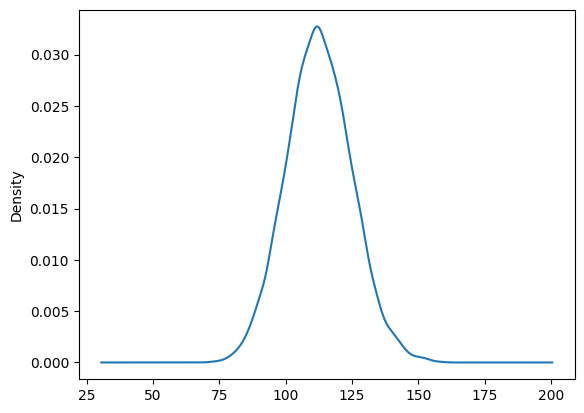

In [101]:
dict_real_values["final_points"]["hpts"].plot(kind = "density")

<Axes: ylabel='Density'>

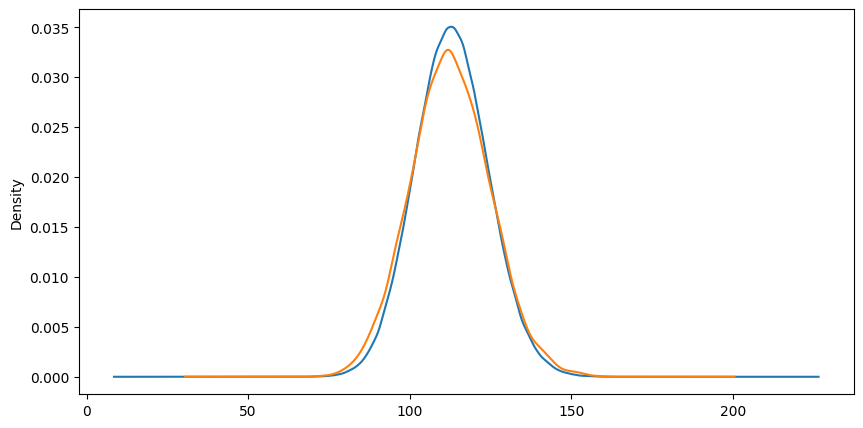

In [102]:
fig, ax = plt.subplots(1,1, figsize = (10, 5))
df_final_points_["home_points"].plot(kind = "density", ax = ax)
dict_real_values["final_points"]["hpts"].plot(kind = "density", ax = ax)

<Axes: ylabel='Density'>

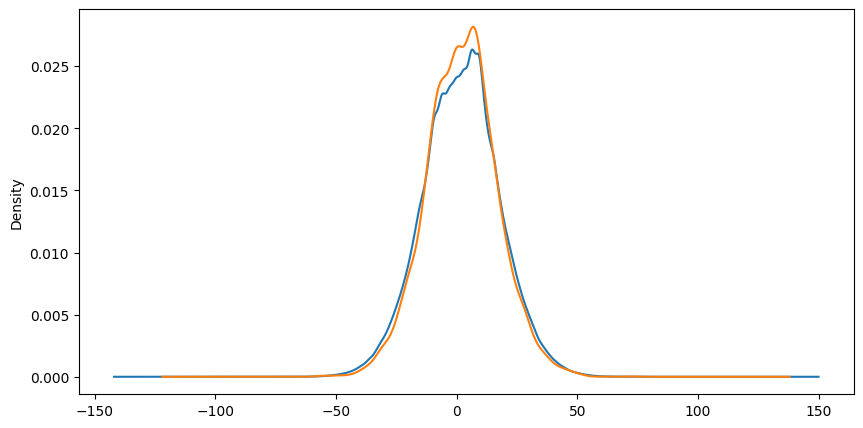

In [103]:
fig, ax = plt.subplots(1,1, figsize = (10, 5))
df_final_points_["dif"].plot(kind = "density", ax = ax)
dict_real_values["final_points"]["dif"].plot(kind = "density", ax = ax)

<Axes: ylabel='Density'>

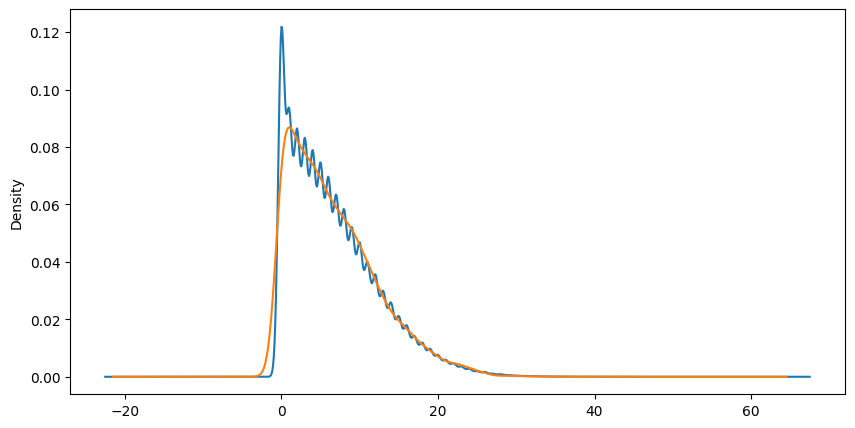

In [104]:
fig, ax = plt.subplots(1,1, figsize = (10, 5))
df_lead_changes_["lead_changes"].plot(kind = "density", ax = ax)
dict_real_values["lead_changes"]["real_lead_changes"].plot(kind = "density", ax = ax)

<Axes: ylabel='Density'>

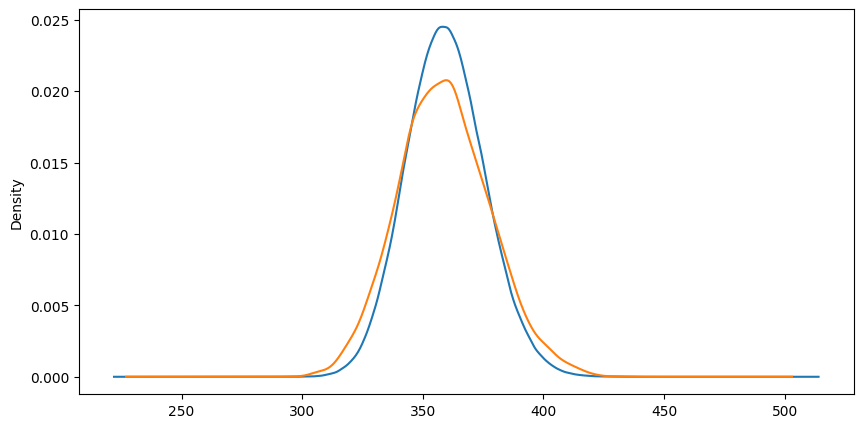

In [105]:
fig, ax = plt.subplots(1,1, figsize = (10, 5))

df_num_plays_.query("period <= 4")\
.reset_index(drop = True).reset_index()\
.assign(parte = lambda df: df.groupby(["seasondata", "sim_id", "period"])["index"].rank())\
.groupby(["seasondata", "sim_id", "parte"], as_index = False, dropna = False)["size"].sum()\
["size"].plot(kind = "density", ax = ax)

dict_real_values["nplays_period"]\
.groupby(["game_id"], as_index = False, dropna = False)["size"].sum()\
["size"].plot(kind = "density", ax = ax)

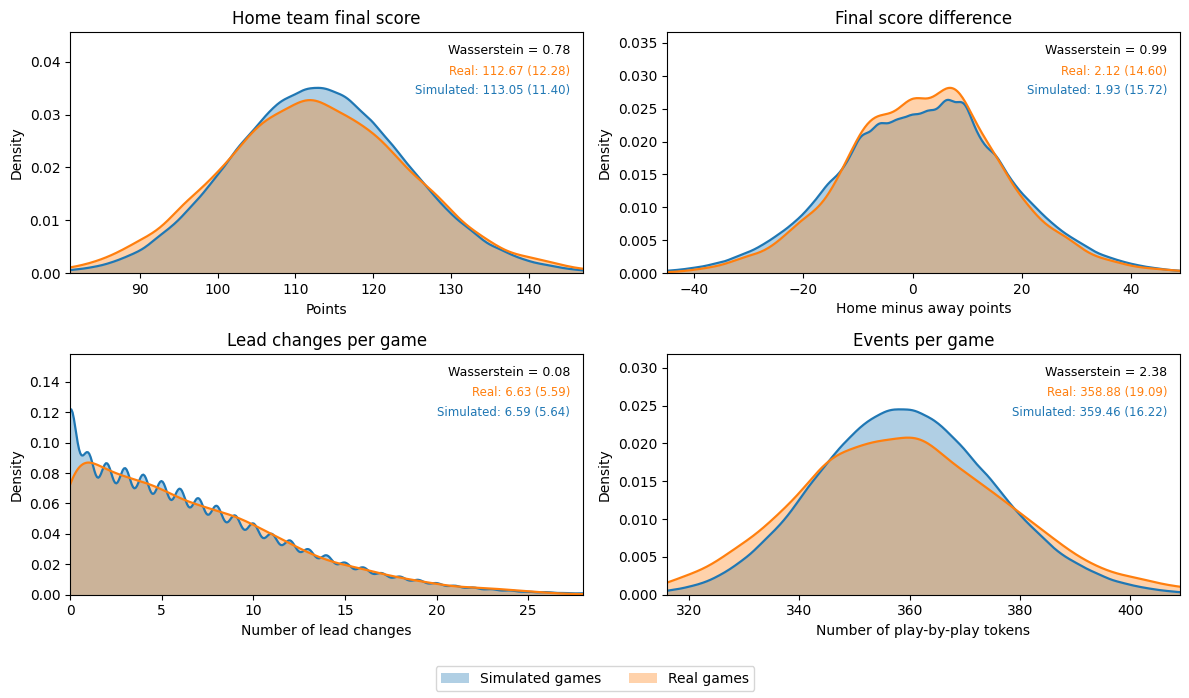

Home team final score      W =   0.78 | real  112.67 +-12.28 | sim  113.05 +-11.40 | n   7098 /  500000
Final score difference     W =   0.99 | real    2.12 +-14.60 | sim    1.93 +-15.72 | n   7098 /  500000
Lead changes per game      W =   0.08 | real    6.63 +- 5.59 | sim    6.59 +- 5.64 | n   7098 /  500000
Events per game            W =   2.38 | real  358.88 +-19.09 | sim  359.46 +-16.22 | n   7098 /  500000


In [113]:
# -*- coding: utf-8 -*-
# =========================================================================
# Painel 2x2 real vs simulado — equivalente ao geom_density(alpha = 0.35)
# do ggplot: poligono preenchido translucido, com a curva por cima.
# Conta como UMA figura. Cole no 22_graficos_sloan.ipynb.
#
# Usa scipy.gaussian_kde, que e exatamente o que o pandas chama por tras do
# kind="density". A unica diferenca e que aqui a curva e preenchida.
#
# Nao mexe em moldura, titulo nem eixo y: o seu estilo prevalece.
# =========================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, wasserstein_distance

COR_SIM, COR_REAL = "C0", "C1"
ALPHA = 0.35

# ------------------------------------------------------------------ dados
sim_nplays = (df_num_plays_
              .query("period <= 4")
              .reset_index(drop=True).reset_index()
              .assign(parte=lambda d: d.groupby(["seasondata", "sim_id", "period"])["index"].rank())
              .groupby(["seasondata", "sim_id", "parte"], as_index=False)["size"].sum()["size"])

real_nplays = (dict_real_values["nplays_period"]
               .query("period <= 4")
               .groupby("game_id")["size"].sum())

PARES = [
    dict(titulo="Home team final score", xlabel="Points",
         real=dict_real_values["final_points"]["hpts"],
         sim=df_final_points_["home_points"], minimo=None),
    dict(titulo="Final score difference", xlabel="Home minus away points",
         real=dict_real_values["final_points"]["dif"],
         sim=df_final_points_["dif"], minimo=None),
    dict(titulo="Lead changes per game", xlabel="Number of lead changes",
         real=dict_real_values["lead_changes"]["real_lead_changes"],
         sim=df_lead_changes_["lead_changes"], minimo=0),
    dict(titulo="Events per game", xlabel="Number of play-by-play tokens",
         real=real_nplays, sim=sim_nplays, minimo=None),
]

# ------------------------------------------------------------------ figura
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for ax, p in zip(axes.ravel(), PARES):
    real = np.asarray(p["real"], dtype=float)
    sim = np.asarray(p["sim"], dtype=float)

    j = np.concatenate([real, sim])
    lo, hi = np.quantile(j, 0.002), np.quantile(j, 0.998)
    if p["minimo"] is not None:
        lo = max(lo, p["minimo"])
    grade = np.linspace(lo, hi, 400)

    d_sim = gaussian_kde(sim)(grade)
    d_real = gaussian_kde(real)(grade)

    ax.fill_between(grade, d_sim, color=COR_SIM, alpha=ALPHA, lw=0,
                    label="Simulated games")
    ax.plot(grade, d_sim, color=COR_SIM, lw=1.6)

    ax.fill_between(grade, d_real, color=COR_REAL, alpha=ALPHA, lw=0,
                    label="Real games")
    ax.plot(grade, d_real, color=COR_REAL, lw=1.6)

    w = wasserstein_distance(real, sim)
    ax.text(0.975, 0.95, "Wasserstein = %.2f" % w, transform=ax.transAxes,
            ha="right", va="top", fontsize=9)
    ax.text(0.975, 0.865, "Real: %.2f (%.2f)" % (real.mean(), real.std()),
            transform=ax.transAxes, ha="right", va="top", fontsize=8.5,
            color=COR_REAL)
    ax.text(0.975, 0.785, "Simulated: %.2f (%.2f)" % (sim.mean(), sim.std()),
            transform=ax.transAxes, ha="right", va="top", fontsize=8.5,
            color=COR_SIM)

    ax.set_title(p["titulo"])
    ax.set_xlabel(p["xlabel"])
    ax.set_ylabel("Density")
    ax.set_xlim(lo, hi)
    ax.set_ylim(0, max(d_sim.max(), d_real.max()) * 1.30)

handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2)
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig("figura_sloan_real_vs_simulado.png", dpi=200, bbox_inches="tight",
            facecolor="white")
plt.show()

# ------------------------------------------------------------------ numeros

for p in PARES:
    r, s = np.asarray(p["real"], float), np.asarray(p["sim"], float)
    print("%-26s W = %6.2f | real %7.2f +-%5.2f | sim %7.2f +-%5.2f | n %6d / %7d"
          % (p["titulo"], wasserstein_distance(r, s),
             r.mean(), r.std(), s.mean(), s.std(), len(r), len(s)))
